# Import Libraries

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [15]:
car = pd.read_csv("car_price_prediction_.csv")

In [16]:
car

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang
...,...,...,...,...,...,...,...,...,...,...
2495,2496,Audi,2020,2.4,Petrol,Automatic,22650,Like New,61384.10,Q5
2496,2497,Audi,2001,5.7,Hybrid,Manual,77701,Like New,24710.35,A3
2497,2498,Ford,2021,1.1,Hybrid,Manual,272827,Like New,29902.45,Fiesta
2498,2499,Audi,2002,4.5,Diesel,Manual,229164,Like New,46085.67,Q5


# Load Dataset

In [17]:
car.shape

(2500, 10)

In [18]:
car.describe()

,Car ID,Year,Engine Size,Mileage,Price
count,2500.00000,2500.0000,2500.000000,2500.000000,2500.000000
mean,1250.50000,2011.6268,3.465240,149749.844800,52638.022532
std,721.83216,6.9917,1.432053,87919.952034,27295.833455
min,1.00000,2000.0000,1.000000,15.000000,5011.270000
25%,625.75000,2005.0000,2.200000,71831.500000,28908.485000
50%,1250.50000,2012.0000,3.400000,149085.000000,53485.240000
75%,1875.25000,2018.0000,4.700000,225990.500000,75838.532500
max,2500.00000,2023.0000,6.000000,299967.000000,99982.590000


# Check Missing Values

In [19]:
car.isnull().sum()

Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64

# Checking Data Types of Dataset

In [20]:
car.dtypes

Car ID            int64
Brand            object
Year              int64
Engine Size     float64
Fuel Type        object
Transmission     object
Mileage           int64
Condition        object
Price           float64
Model            object
dtype: object

# Filtering Required Columns

In [21]:
filter_data = car[["Car ID","Year","Mileage"]]

In [22]:
filter_data

,Car ID,Year,Mileage
0,1,2016,114832
1,2,2018,143190
2,3,2013,181601
3,4,2011,68682
4,5,2009,223009
...,...,...,...
2495,2496,2020,22650
2496,2497,2001,77701
2497,2498,2021,272827
2498,2499,2002,229164


# Remove Duplicates

In [23]:
car.drop_duplicates

<bound method DataFrame.drop_duplicates of       Car ID   Brand  Year  Engine Size Fuel Type Transmission  Mileage  \
0          1   Tesla  2016          2.3    Petrol       Manual   114832   
1          2     BMW  2018          4.4  Electric       Manual   143190   
2          3    Audi  2013          4.5  Electric       Manual   181601   
3          4   Tesla  2011          4.1    Diesel    Automatic    68682   
4          5    Ford  2009          2.6    Diesel       Manual   223009   
...      ...     ...   ...          ...       ...          ...      ...   
2495    2496    Audi  2020          2.4    Petrol    Automatic    22650   
2496    2497    Audi  2001          5.7    Hybrid       Manual    77701   
2497    2498    Ford  2021          1.1    Hybrid       Manual   272827   
2498    2499    Audi  2002          4.5    Diesel       Manual   229164   
2499    2500  Toyota  2005          4.6    Diesel    Automatic    80978   

     Condition     Price     Model  
0          New  266

# Train Model

In [32]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Model Evaluation

In [34]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 24202.7420072
MSE : 794899039.0511985
RMSE : 28193.953944971934
R2 Score : -0.0492977922157507


# Actual vs Predicted Graph

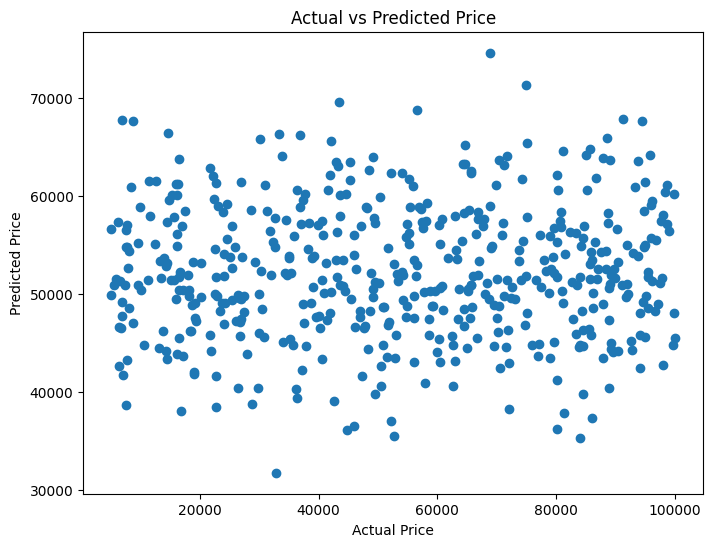

In [35]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

# Feature Importance

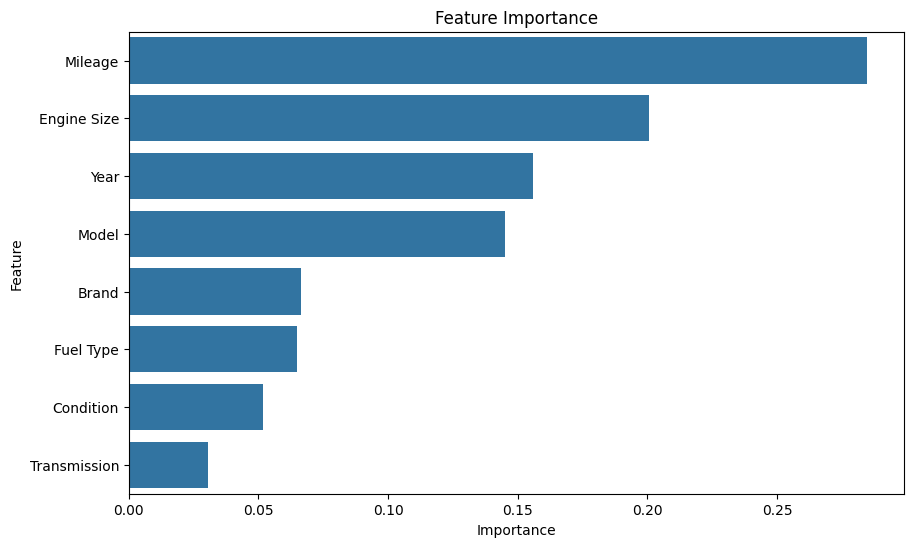

In [36]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})
importance = importance.sort_values(
    by='Importance',
    ascending=False
)
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)
plt.title("Feature Importance")
plt.show()

# Predict a New Car Price

In [37]:
sample_car = X.iloc[[0]]
predicted_price = model.predict(sample_car)
print("Predicted Price:", predicted_price[0])

Predicted Price: 33798.496699999945


# Correlation Analysis

In [38]:
correlation = car.corr(numeric_only=True)
correlation['Price'].sort_values(ascending=False)

Price           1.000000
Brand           0.001315
Transmission   -0.001877
Engine Size    -0.004420
Mileage        -0.008567
Condition      -0.015669
Model          -0.032302
Fuel Type      -0.034958
Year           -0.036805
Name: Price, dtype: float64

# Visualize Correlation Heatmap

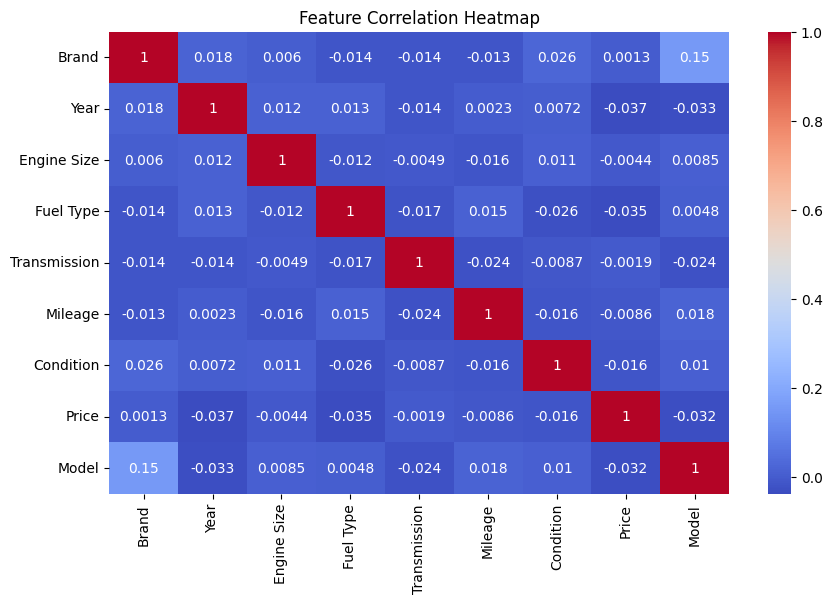

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.heatmap(
    car.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)
plt.title("Feature Correlation Heatmap")
plt.show()

# Feature Importance Analysis

In [40]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})
importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
5,Mileage,0.285580
2,Engine Size,0.197783
1,Year,0.158495
7,Model,0.145351
0,Brand,0.066271
3,Fuel Type,0.064914
6,Condition,0.051734
4,Transmission,0.029872


# Price Distribution

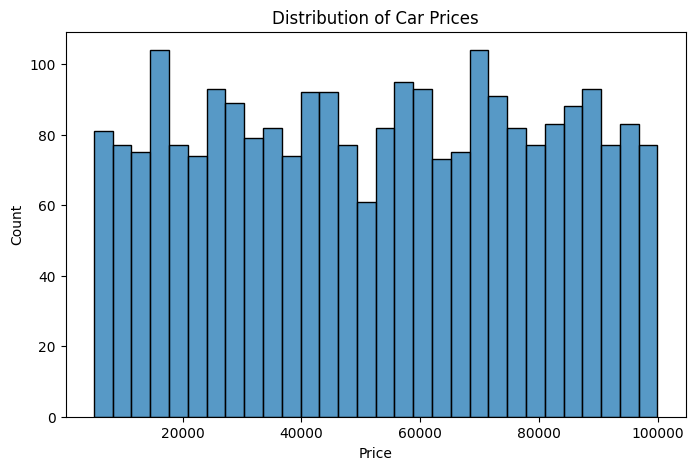

In [41]:
plt.figure(figsize=(8,5))
sns.histplot(car['Price'], bins=30)
plt.title("Distribution of Car Prices")
plt.show()

# Outlier Detection

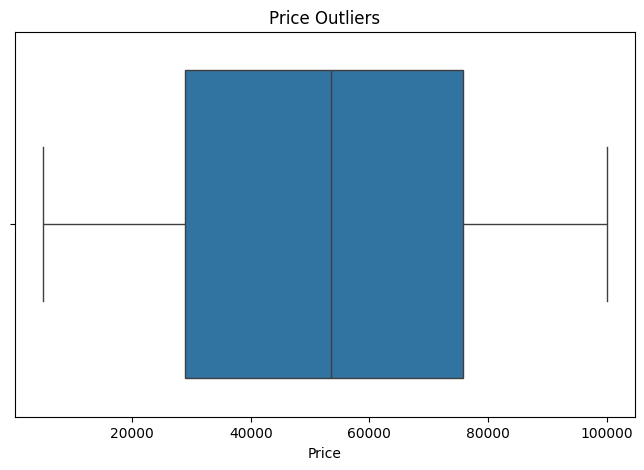

In [42]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x=car['Price']
)
plt.title("Price Outliers")
plt.show()

# Actual vs Predicted Prices

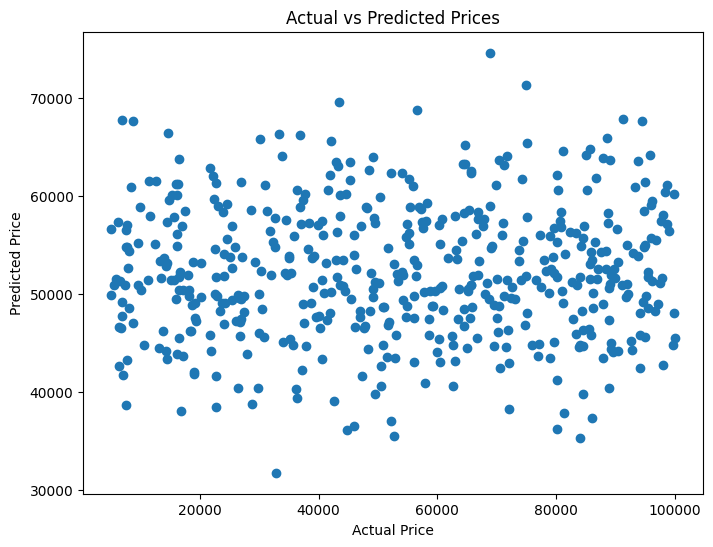

In [43]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()